<a href="https://colab.research.google.com/github/Lamiya-56/internship-data-analytics/blob/main/Basic_EDA_on_Supermarket_Sales_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
!wget https://raw.githubusercontent.com/cwentz12/Supermarket-Sales-Analysis/refs/heads/main/Data/supermarket_sales%20-%20Sheet1.csv

--2026-04-25 19:57:45--  https://raw.githubusercontent.com/cwentz12/Supermarket-Sales-Analysis/refs/heads/main/Data/supermarket_sales%20-%20Sheet1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 131528 (128K) [text/plain]
Saving to: ‘supermarket_sales - Sheet1.csv.2’

supermarket_sales - 100%[===================>] 128.45K  --.-KB/s    in 0.003s  

2026-04-25 19:57:45 (36.8 MB/s) - ‘supermarket_sales - Sheet1.csv.2’ saved [131528/131528]



In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df=pd.read_csv('/content/supermarket_sales - Sheet1.csv')
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


In [59]:
df.shape

(1000, 17)

In [60]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [61]:
df.dtypes

,0
Invoice ID,object
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Total,float64


In [62]:
df['Date']=pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')

In [63]:
df.dtypes

,0
Invoice ID,object
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Total,float64


In [64]:
df['Branch'].value_counts()

,count
Branch,
A,340
B,332
C,328


In [65]:
df.groupby('Product line')['Total'].sum().sort_values(ascending=False)

,Total
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


In [66]:
df['Customer type'].value_counts(normalize=True)*100

,proportion
Customer type,
Member,50.1
Normal,49.9


In [67]:
print(f"Average rating: {df['Rating'].mean()}")
df.groupby('Branch')['Rating'].mean()

Average rating: 6.9727


,Rating
Branch,
A,7.027059
B,6.818072
C,7.072866


In [68]:
df['Hours']=df['Time'].dt.hour
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hours
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,13
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,20
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,2019-01-29,1900-01-01 13:46:00,Ewallet,40.35,4.761905,2.0175,6.2,13
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,2019-03-02,1900-01-01 17:16:00,Ewallet,973.80,4.761905,48.6900,4.4,17
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2019-02-09,1900-01-01 13:22:00,Cash,31.84,4.761905,1.5920,7.7,13
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2019-02-22,1900-01-01 15:33:00,Cash,65.82,4.761905,3.2910,4.1,15


In [69]:
df.groupby('Hours')['Total'].sum().sort_values()

,Total
Hours,
20,22969.5270
17,24445.2180
16,25226.3235
18,26030.3400
12,26065.8825
11,30377.3295
14,30828.3990
15,31179.5085
10,31421.4810


In [70]:
df['Month']=df['Date'].dt.month_name()
df.groupby('Month')['Total'].sum().sort_values(ascending=False)

,Total
Month,
January,116291.868
March,109455.507
February,97219.374


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   datetime64[ns]
 12  Payment                  1000 non-n

In [72]:
result = df.groupby(['Branch', 'Product line', 'Customer type', 'Gender']).agg(total_sales=('Total', 'sum'),order_count=('Invoice ID', 'count')).reset_index()
result

,Branch,Product line,Customer type,Gender,total_sales,order_count
0,A,Electronic accessories,Member,Female,3946.6350,12
1,A,Electronic accessories,Member,Male,5199.0540,19
2,A,Electronic accessories,Normal,Female,6019.6605,16
3,A,Electronic accessories,Normal,Male,3151.7640,13
4,A,Fashion accessories,Member,Female,4191.3585,12
...,...,...,...,...,...,...
67,C,Home and lifestyle,Normal,Male,4009.6770,11
68,C,Sports and travel,Member,Female,5422.2000,15
69,C,Sports and travel,Member,Male,2715.0900,13
70,C,Sports and travel,Normal,Female,5824.5285,14


In [73]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hours,Month
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,January
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,March
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,13,March
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,20,January
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,10,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,2019-01-29,1900-01-01 13:46:00,Ewallet,40.35,4.761905,2.0175,6.2,13,January
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,2019-03-02,1900-01-01 17:16:00,Ewallet,973.80,4.761905,48.6900,4.4,17,March
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2019-02-09,1900-01-01 13:22:00,Cash,31.84,4.761905,1.5920,7.7,13,February
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2019-02-22,1900-01-01 15:33:00,Cash,65.82,4.761905,3.2910,4.1,15,February


In [74]:
product_performance=df.groupby('Product line')['Total'].sum().sort_values(ascending=False)

top_performing=product_performance.head(1)
bottom_performing=product_performance.tail(1)

product_performance

,Total
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


In [75]:
top_performing

,Total
Product line,
Food and beverages,56144.844


In [76]:
bottom_performing

,Total
Product line,
Health and beauty,49193.739


##Visualizations

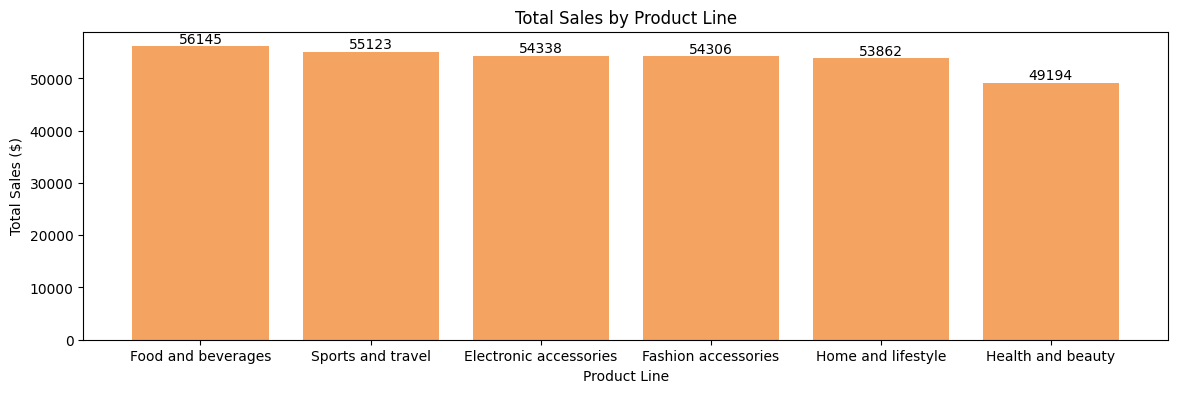

In [77]:
product_performance=product_performance.reset_index()

plt.figure(figsize=(14, 4))
bars=plt.bar(product_performance['Product line'], product_performance['Total'], color='sandybrown')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.0f}',
             ha='center', va='bottom')
plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales ($)')
plt.show()

Satışlar bütün kateqoriyalar arasında çox bərabər paylanıb. Food and beverages (təqribən 56k) birinci, Health and beauty (49k) isə sonuncudur.

Biznesin portfoliosu çoxşaxəlidir və bir məhsuldan kəskin asılılıq yoxdur, bu da riskin paylanması üçün çox yaxşıdır.

Health and beauty məhsulları 49 minlə bir az geridə qalır. Bu nəticə məhsulların keyfiyyəti ilə deyil, həmin kateqoriyanın bazar tələbi və cari marketinq strategiyasının effektivliyi ilə bağlı ola bilər. Sadəcə, bu sahəyə bir az daha çox diqqət (məsələn, bir az daha çox reklam və ya endirim kampaniyası) ayrılsa, satışlar digər 5 məhsulun səviyyəsinə qaldırıla bilər.

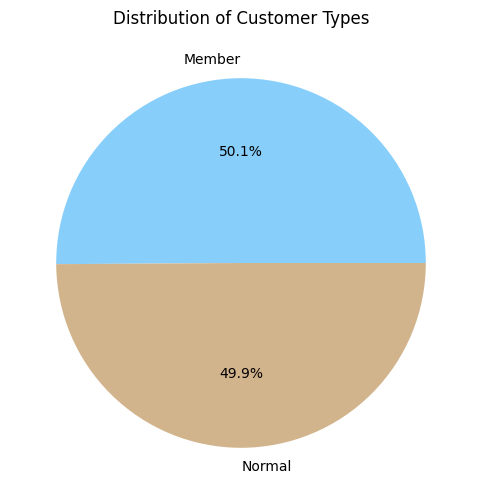

In [78]:
plt.figure(figsize=(10, 6))

customer_counts=df['Customer type'].value_counts()
customer_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightskyblue', 'tan'])
plt.title('Distribution of Customer Types')
plt.ylabel('') # Hiding y-label for cleaner look
plt.show()

50.1% və 49.9% nisbəti, müştəri bazasızın loyallıq proqramına cəlb olunmuş ("Member") və edilməmiş ("Normal") hissələr arasında mükəmməl bir tarazlıqda olduğunu göstərir. Bu, biznesdə hər iki seqmentin bərabər dərəcədə dominant olduğunu təsdiqləyir.

Bu bərabərlik, "Normal" qrupunun strateji bir fürsət olduğunu göstərir. Çünki bazarın yarısı artıq loyaldır, digər yarısı isə proqrama cəlb edilməyi gözləyən potensial namizədlərdir.

Əgər üzv (Member) olan müştərilər biznesə daha çox qazanc gətirirsə, 'Normal' müştəriləri üzvlüyə cəlb etmək gəliri artırmağın ən effektiv yoludur. Bunun üçün onları üzv olmağa həvəsləndirən xüsusi kampaniyalar keçirmək kifayətdir.

In [79]:
hourly_sales = df.groupby('Hours')['Total'].sum().sort_index()
hourly_sales

,Total
Hours,
10,31421.4810
11,30377.3295
12,26065.8825
13,34723.2270
14,30828.3990
15,31179.5085
16,25226.3235
17,24445.2180
18,26030.3400


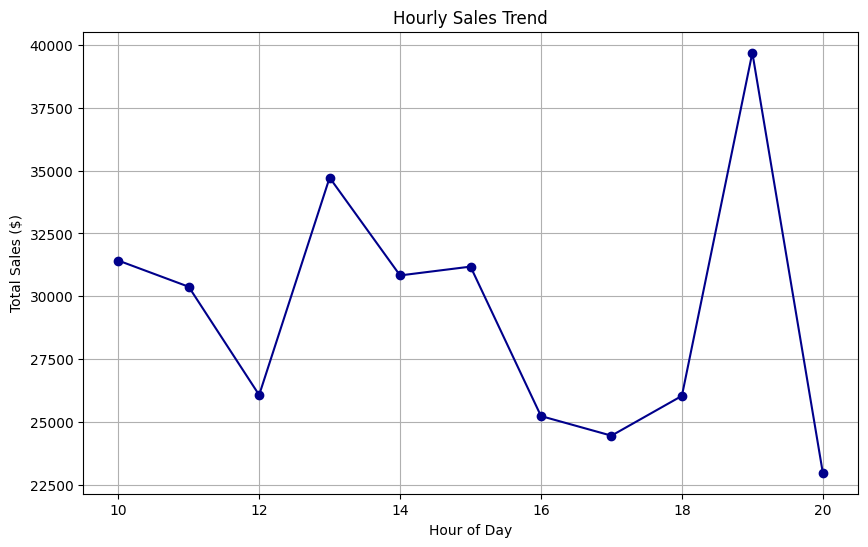

In [80]:
plt.figure(figsize=(10, 6))

plt.plot(hourly_sales.index, hourly_sales.values, marker='o', color='darkblue')
plt.title('Hourly Sales Trend')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.show()

Zirvə Nöqtələri: Satışlar 13:00 (34,500) və xüsusilə 19:00 (40,000) saatlarında pik nöqtəsinə çatır. Bu saatlar günün ən gəlirli anlarıdır.
Sakit Saatlar: 12:00 və 17:00 saatları satışların ən çox düşdüyü, "ölü" zonalar hesab edilə bilər.

Kəskin Eniş: Saat 20:00-da satışların sürətlə düşməsi, mağazanın bağlanış vaxtına və ya həmin saatda müştəri marağının tamamilə bitdiyinə işarə edir.


---


İşçi Qüvvəsinin Planlaması: Personalı 13:00 və 19:00-dakı yüksək tələbata uyğun olaraq daha çox cəmləşdirmək - bu, xidmət keyfiyyətini və satış sürətini artıracaq.

12:00 və 17:00-dakı "sakit" anlarda işçilərin sayını azalda və ya onları digər əməliyyat işlərinə (təmizlik, stok yeniləmə) yönəldərək xərclərə qənaət edilə bilər.

Promosyon Strategiyası: 17:00-dakı satış boşluğunu doldurmaq üçün həmin saatlara özəl endirimləri və ya qısa müddətli kampaniyalar tətbiq edərək o saatlardakı müştəri marağını artıra bilərik.

In [81]:
margin_df = df.groupby('Product line').agg({
    'Total': 'sum',
    'gross income': 'sum'
})

margin_df['gross Margin %'] = (margin_df['gross income'] / margin_df['Total']) * 100
margin_df

,Total,gross income,gross Margin %
Product line,,,
Electronic accessories,54337.5315,2587.5015,4.761905
Fashion accessories,54305.8950,2585.9950,4.761905
Food and beverages,56144.8440,2673.5640,4.761905
Health and beauty,49193.7390,2342.5590,4.761905
Home and lifestyle,53861.9130,2564.8530,4.761905
Sports and travel,55122.8265,2624.8965,4.761905


In [82]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hours,Month
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,January
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,March
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,13,March
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,20,January
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,10,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,2019-01-29,1900-01-01 13:46:00,Ewallet,40.35,4.761905,2.0175,6.2,13,January
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,2019-03-02,1900-01-01 17:16:00,Ewallet,973.80,4.761905,48.6900,4.4,17,March
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2019-02-09,1900-01-01 13:22:00,Cash,31.84,4.761905,1.5920,7.7,13,February
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2019-02-22,1900-01-01 15:33:00,Cash,65.82,4.761905,3.2910,4.1,15,February


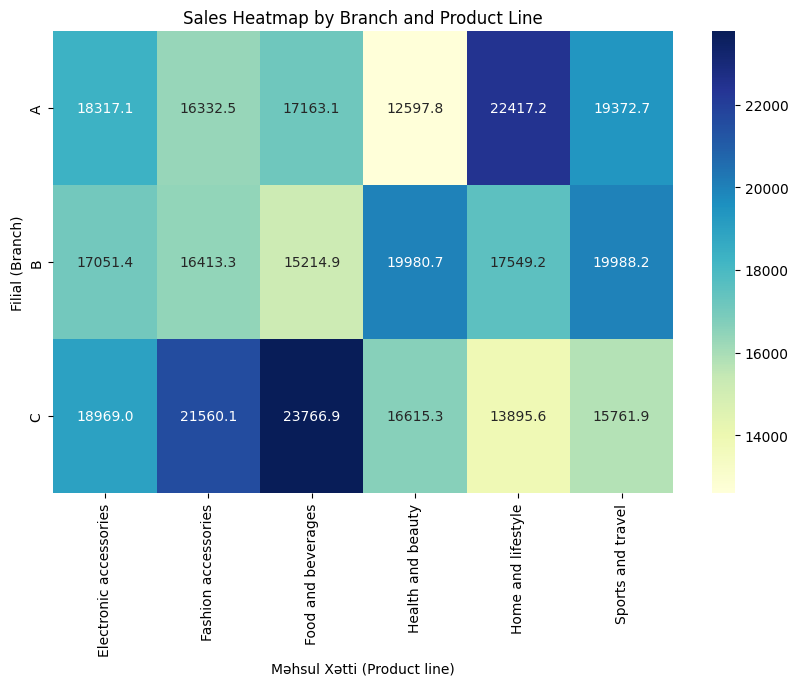

In [83]:
heatmap_data = df.pivot_table(index='Branch',
                              columns='Product line',
                              values='Total',
                              aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Sales Heatmap by Branch and Product Line')
plt.ylabel('Filial (Branch)')
plt.xlabel('Məhsul Xətti (Product line)')
plt.show()

Ümumi qrafikdə "Health and beauty" ən zəif kateqoriya kimi görünür. Lakin heatmap-ə baxdıqda, bunun ümumi problem deyil, filialdan asılı bir problem olduğunu görürük:

Filial B bu kateqoriyada çox güclüdür (19.9k).

Filial A isə bu kateqoriyada çox aşağı performans göstərir (12.6k).

Təklif: "Health and beauty" kateqoriyasında Filial A-nın satışlarını artırmaq üçün Filial B-də tətbiq olunan satış taktikalarını (məsələn, məhsulun yerləşdirilməsi, satış heyətinin təlimi və ya promo kampaniyalar) Filial A-ya inteqrasiya etmək ümumi dövriyyəni dərhal artıra bilər.


---

Filial C: Həm "Fashion accessories" (21.5k), həm də "Food and beverages" (23.7k) üzrə ən yüksək satış göstəricisinə malikdir.

Filial A: 22,417 $ ilə "Home and lifestyle" kateqoriyasında ən yüksək performansa malikdir.

Biz görürük ki, "Fashion accessories" kateqoriyasında Filial C ən yüksək performansa malikdir. Bu, bizim üçün bir siqnaldır: biz həmin məhsulları satışın daha zəif olduğu filiallarda gözlətməməli, ehtiyatları Filial C-yə yönəltməliyik.

Belə etməklə biz iki vacib hədəfə nail oluruq:

Satış sürətini artırırıq: Malı onu almağa hazır olan müştərinin qarşısına qoyuruq.

Dövriyyəni sürətləndiririk: Kapitalımızı rəfdə qalan məhsula deyil, tez satılan məhsula bağlayırıq.
